# MCD8009: Data Discovery - Laboratorio 4

**Integrantes**

| N° | Código | Nombres |  Contribución (0% - 100%) |
|----|--------|---------|---------------------------|
| 1  |        | Jhomar Yurivilca        |          100%                 |
| 2  |        |  Hugo Ángeles       |        100%                   |
| 3  |        |  Christian Cajusol       |          100%                 |
| 4  |        |   Francisco Meza      |           100%                |

### Indicaciones

- El laboratorio podrá resolverse de manera **individual o en equipos de hasta cuatro (4) personas**. Deberán completar los datos de todos los integrantes, y **una sola persona realizará la entrega del archivo ipynb**.

- Salvo que se indique explícitamente lo contrario, no se prohibe el uso de herramientas de Inteligencia Artificial Generativa, siempre que los integrantes comprendan y puedan explicar el proceso y los resultados obtenidos. **Las respuestas no deben consistir en transcripciones literales de resultados generados por estas herramientas, sino evidenciar comprensión del tema por parte del estudiante o del equipo.**

- En caso de utilizar herramientas de IA Generativa, cada equipo es responsable de verificar la coherencia de las respuestas presentadas. Si se detectan errores, inconsistencias o falta de comprensión, la pregunta podrá ser anulada sin derecho a reclamo.

- En todos los casos, deberá completarse la **Declaración de Uso de IA Generativa.**

- Pueden agregar libremente celdas de código o de Markdown según lo consideren conveniente.

### Declaración de uso de IA Generativa
- Indicar de manera breve la(s) herramienta(s) y/o modelo(s) de IA Generativa utilizados, especificando en qué pregunta(s) se emplearon y con qué propósito.
- En caso no se haya usado, también indicarlo.

Durante el desarrollo del laboratorio se usó IA generativa, los modelos Gemini 3 y Opus 4.6. En la parte 3, para que me ayude con el preprocesamiento de los datos y las visualizaciones.

El prompt que se empleó fue:
Segun el diccionario de datos compartido y los archivos csv, genera un código en python para el scaffolding del procesamiento de datos, feature engineering y la generación de gráficos.

Durante el proceso de generación de gráficos se iteraron los resultados del agente para cada gráfico, proporcionandole el contexto adecuado dada la historia que queriamos contar junto con el uso de buenas prácticas de visualización de datos.

## INICIO DEL LABORATORIO

### Parte 1: Feature engineering (5 puntos)

De la actividad grupal en clase de `Ideas de Feature engineering`, implemente 6 variables, de las cuales:
- Al menos una debe ser un encoding.
- Al menos una debe ser un escalado.
- Al menos una debe ser una discretización.
- Al menos una debe ser la creación de una nueva variable.

Además indique, para cada variable, qué técnica ha empleado.

Puede inspirarse de las propuestas de sus compañeros. (3 puntos)
- [Ideas de la sección 1](https://docs.google.com/presentation/d/1NctqdJAIoCf65jZgmKDR2ABQRB-JVE_BFyymi5K5Xss/edit?usp=sharing)
- [Ideas de la sección 2](https://docs.google.com/presentation/d/1uHzKY3laNwRZpQF5EC1UrcsbnBMnt6r1PeVImX-5gBE/edit?usp=sharing)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
# 1. Encoding Binario
# Transformamos la variable categórica Central Air ('Y'/'N') en valores numéricos (1/0)
df['CentralAir_Enc'] = df['Central Air'].map({'Y': 1, 'N': 0})

# 2. Escalado Min-Max
# Normalizamos el área del lote (Lot Area) a un rango entre 0 y 1 para facilitar la convergencia de modelos
min_la = df['Lot Area'].min()
max_la = df['Lot Area'].max()
df['LotArea_Scaled'] = (df['Lot Area'] - min_la) / (max_la - min_la)

# 3. Discretización
# Agrupamos el año de construcción en 4 categorías: 'Very Old', 'Old', 'Modern' y 'New' (según conocimiento del negocio) usando intervalos de tiempo
df['YearBuilt_Bin'] = pd.cut(df['Year Built'],
                             bins=[0, 1950, 1980, 2000, 2024],
                             labels=['Very Old', 'Old', 'Modern', 'New'])

# 4. Nueva Variable: Superficie Total
# Creamos una nueva variable de pies cuadrados totales sumando el área del primer piso, segundo piso y el sótano total (1st Flr SF + 2nd Flr SF + Total Bsmt SF)
df['TotalSF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF'].fillna(0)

# 5. Nueva Variable: Edad de la casa al venderla
# Calculamos como nueva variable la edad de la casa al momento de la venta restando el año de construcción del año de venta (Yr Sold - Year Built)
df['HouseAgeAtSale'] = df['Yr Sold'] - df['Year Built']

# 6. Label Encoding
# Asignamos un valor numérico (1 a 5) a la calidad de la cocina (Kitchen Qual) respetando su orden lógico (de 'Po' a 'Ex').
# Se sabe el diccionario de datos para la variable Kitchen Qual {Ex: Excellent, Gd: Good, TA: Typical/Average, Fa: Fair, Po: Poor}
kitchen_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
df['KitchenQual_Ord'] = df['Kitchen Qual'].map(kitchen_map)

Ahora grafique algunos de sus nuevos features (ya sea mediante gráficos univariados o multivariados) e indique dos descubrimientos interesantes o conclusiones que le brindó esta nueva perspectiva. (2 puntos)

/tmp/ipykernel_2046/352449231.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='YearBuilt_Bin', y='SalePrice', palette='viridis', ax=axes[1],


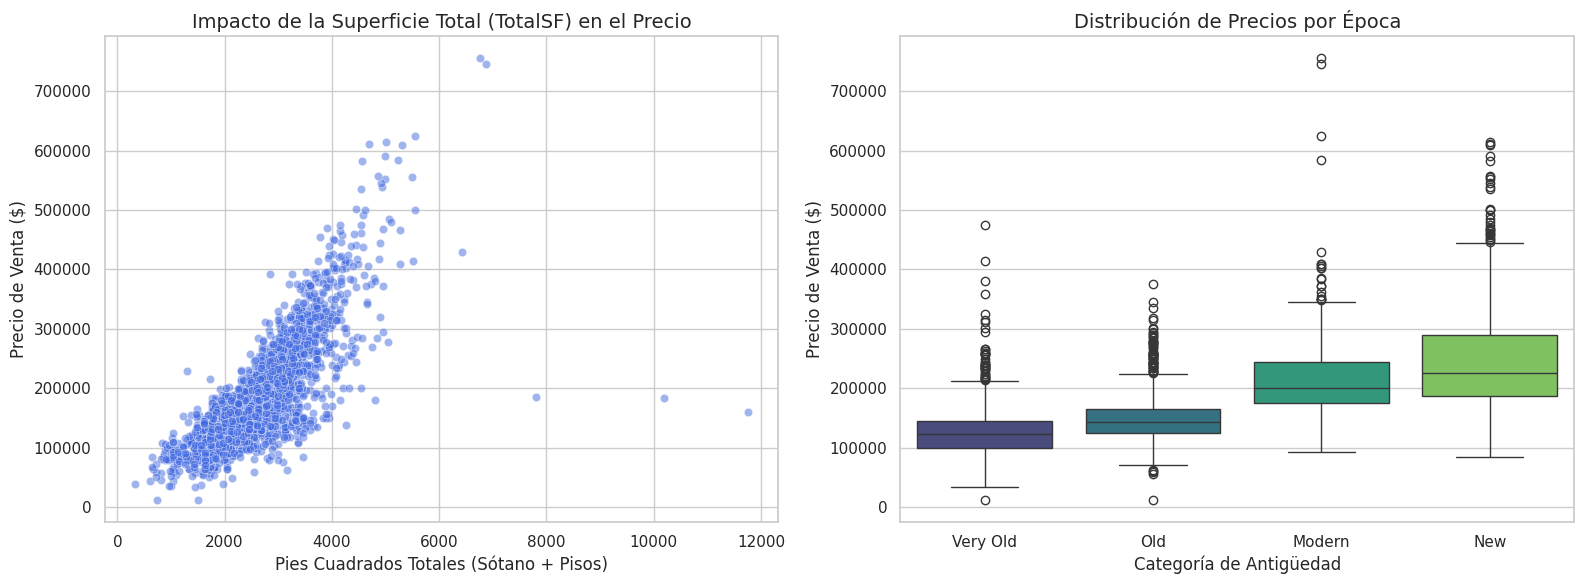

/tmp/ipykernel_2046/352449231.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='KitchenQual_Ord', palette='magma')


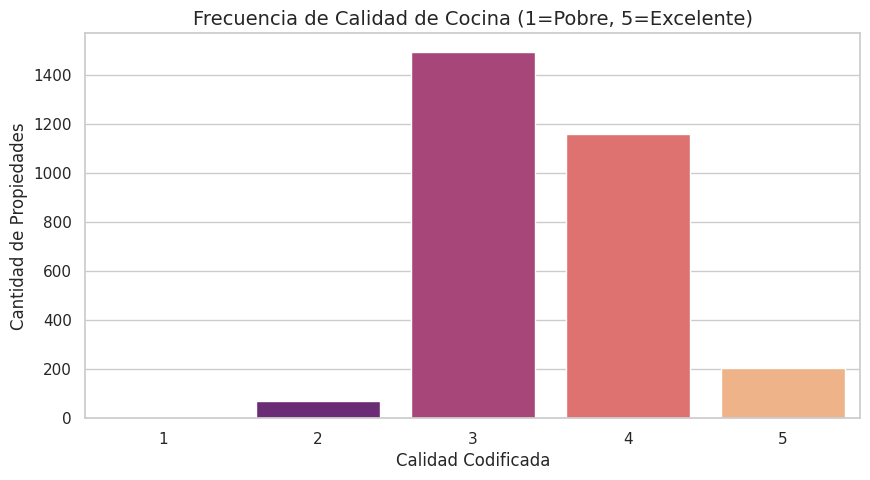

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (Multivariados)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Relación entre Tamaño Total y Precio
sns.scatterplot(data=df, x='TotalSF', y='SalePrice', alpha=0.5, ax=axes[0], color='royalblue')
axes[0].set_title('Impacto de la Superficie Total (TotalSF) en el Precio', fontsize=14)
axes[0].set_xlabel('Pies Cuadrados Totales (Sótano + Pisos)')
axes[0].set_ylabel('Precio de Venta ($)')

# Gráfico 2: Precio según la Época de Construcción
sns.boxplot(data=df, x='YearBuilt_Bin', y='SalePrice', palette='viridis', ax=axes[1],
            order=['Very Old', 'Old', 'Modern', 'New'])
axes[1].set_title('Distribución de Precios por Época', fontsize=14)
axes[1].set_xlabel('Categoría de Antigüedad')
axes[1].set_ylabel('Precio de Venta ($)')

plt.tight_layout()
plt.show()

# Gráfico 3: Distribución Univariada de Calidad de Cocina (Ordinal)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='KitchenQual_Ord', palette='magma')
plt.title('Frecuencia de Calidad de Cocina (1=Pobre, 5=Excelente)', fontsize=14)
plt.xlabel('Calidad Codificada')
plt.ylabel('Cantidad de Propiedades')
plt.show()

- En el primer gráfico de dispersión podemos observar una fuerte correlación entre la nueva variable creada (TotalSF) y el precio de venta. Esto indica que unificar las medidas de área en una sola variable simplifica el modelo sin perder información esencial.
- En el segundo gráfico, existe un "salto" de precio notable cuando pasamos de casas calificadas como "Old" (construidas entre 1950-1980) a "Modern" (1980-2000). Mientras que las casas más antiguas tienen medianas de precio cercanas a los $124,000 - $142,000, las casas modernas y nuevas superan los $200,000.
- Al observar el gráfico de barras de KitchenQual_Ord, vemos que la gran mayoría de las casas tienen una calificación de 3 (Típica/Promedio).

### Parte 2: Teoría (3 puntos) [Sin uso de herramientas de IA generativa]

Responda las siguientes preguntas (1pto cada uno):

a) ¿En qué medida la sobrecarga visual puede ser contraproducente en el descubrimiento de datos? ¿Cómo se pueden minimizar este problema?

b) ¿Qué riesgos existen al basar decisiones en patrones identificados a través de Visual Data Discovery, considerando que las visualización NO son neutrales?

c) ¿Cómo se pueden mitigar los efectos de la manipulación visual en la toma de decisiones basada en datos?

Respuestas:

a) La sobrecarga visual puede llegar a ser contraproducente en el descubrimiento de datos en la medida que la cantidad de estimulos visuales supera lo que una persona puede retener. Ante un exceso la persona puede sentirse abrumada y no puede decidir por donde empezar.
Se puede minimizar el problema cuando primero somos conscientes de que existe una sobrecargar de estímulos y en consiguiente aplicar principio de diseño centrado en el usuario, asi como aplicar un criterio de jerarquia visual en la que guiamos la atencion hacia los mas importante.

b) Los riesgos en lo que se podría caer es principalmente en el sezgo, porque las visualizaciones en mayor medida son construcciones interpretativas. La persona que diseña el gráfico toma decisiones de que incluir, excluir y como mostrarlo.

c) Se deben implementar estrategias tanto a nivel técnico como de negocio. La idea principal no es dejar de usar gráficos, sino aprender a consumirlos y producirlos de manera crítica y responsable. Una medida de mitigacíon seriá que al momento de graficar las variables se establezca que los ejes empiecen en cero y la proporcionalidad, relación adecuada entre las dimensiones. Otra estrategia seria revisar por pares los graficos antes de presentar los hallazgos, esto permitira que en observador que no construyó el gráfico detecte más fácilmente sesgos de presentación o información omitida.

### Parte 3: Trabajo integrador (12 puntos)

Este ejercicio consiste en aplicar **Visual Data Discovery** para identificar patrones en un dataset. En particular, trabajaremos con un dataset sobre **pérdidas de clientes en Telco**, una empresa del sector telecomunicaciones. El objetivo es **identificar factores de riesgo de abandono (churn)**, lo que permitirá desarrollar estrategias de **retención de clientes** y respaldar **decisiones informadas en un contexto de negocio**.  

El entregable es el notebook que presente:
- El desarrollo (proceso) del EDA (formato libre).
- Una sección ejecutiva que incluya:
    - 4 o 5 visualizaciones clave, indicando la historia que cuenta cada gráfico en relación con la problemática.
    - Al menos 3 recomendaciones estratégicas enfocándose en insights accionables, los cuales sean respaldados por las visualizaciones realizadas anteriormente.

#### **Objetivos del Análisis**  
1. Detectar patrones y segmentos de clientes con alto riesgo de churn.
2. Identificar factores críticos que contribuyen a la pérdida de clientes.
3. Proponer estrategias basadas en los hallazgos para reducir la tasa de abandono.
4. Presentar los resultados de manera clara y accionable para la toma de decisiones.
   
#### **Consideraciones para las visualizaciones**  
- Preparar visualizaciones que resalten los hallazgos clave.
- Utilizar gráficos claros y concisos, asegurándose de que respalden las recomendaciones para la toma de decisiones.  
- Aplicar buenas prácticas en visualización de datos.

#### **Consideraciones para las recomendaciones estratégicas**  
- Con base en los resultados obtenidos, desarrollar estrategias de retención específicas.  
- Justificar cómo estas recomendaciones podrían reducir el churn y el impacto que tendrían en el negocio.  

#### **Nota:**
- La calificación tomará en cuenta el orden y presentación del cuadernillo, la claridad y diseño de los gráficos, y la calidad de las recomendaciones.

### Declarar librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

CHURN_COLOR   = '#E74C3C'
RETAIN_COLOR  = '#2ECC71'
NEUTRAL_COLOR = '#3498DB'

demographics = pd.read_csv("Telco_customer_churn_demographics.csv")
location = pd.read_csv("Telco_customer_churn_location.csv")
population = pd.read_csv("Telco_customer_churn_population.csv")
status = pd.read_csv("Telco_customer_churn_status.csv")
services = pd.read_csv("Telco_customer_churn_services.csv")

### Unir los datasets

In [ ]:
location_pop = location.merge(population[['Zip Code', 'Population']], on='Zip Code', how='left')

df = (demographics
      .merge(services,     on='Customer ID', suffixes=('', '_svc'))
      .merge(status,       on='Customer ID', suffixes=('', '_sta'))
      .merge(location_pop, on='Customer ID', suffixes=('', '_loc')))

# Eliminar columnas Count duplicadas
count_cols = [c for c in df.columns if c.startswith('Count') and c != 'Count']
df.drop(columns=count_cols, inplace=True)

# Variable objetivo
df['Churned'] = df['Churn Value'].astype(int)

# Segmento de antigüedad
df['Tenure_Segment'] = pd.cut(
    df['Tenure in Months'],
    bins=[0, 6, 12, 24, 48, 120],
    labels=['0-6 m', '7-12 m', '13-24 m', '25-48 m', '48+ m']
)

# Segmento de densidad poblacional
df['Pop_Segment'] = pd.qcut(
    df['Population'],
    q=4,
    labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta']
)

print(f'Dataset final: {df.shape[0]} clientes × {df.shape[1]} variables')
print(f'Tasa de churn global: {df.Churned.mean()*100:.1f}%')
df.head(3)

Dataset final: 7043 clientes × 52 variables
Tasa de churn global: 26.5%


,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Quarter,...,Churn Reason,State,City,Zip Code,Latitude,Longitude,Population,Churned,Tenure_Segment,Pop_Segment
0,8779-QRDMV,1,M,78,No,Yes,No,No,0,Q3,...,Competitor offered more data,California,Los Angeles,90022,34.023810,-118.156582,68701,1,0-6 m,Alta
1,7495-OOKFY,1,F,74,No,Yes,Yes,Yes,1,Q3,...,Competitor made better offer,California,Los Angeles,90063,34.044271,-118.185237,55668,1,7-12 m,Alta
2,1658-BYGOY,1,M,71,No,Yes,No,Yes,3,Q3,...,Competitor made better offer,California,Los Angeles,90065,34.108833,-118.229715,47534,1,13-24 m,Alta


### EDA

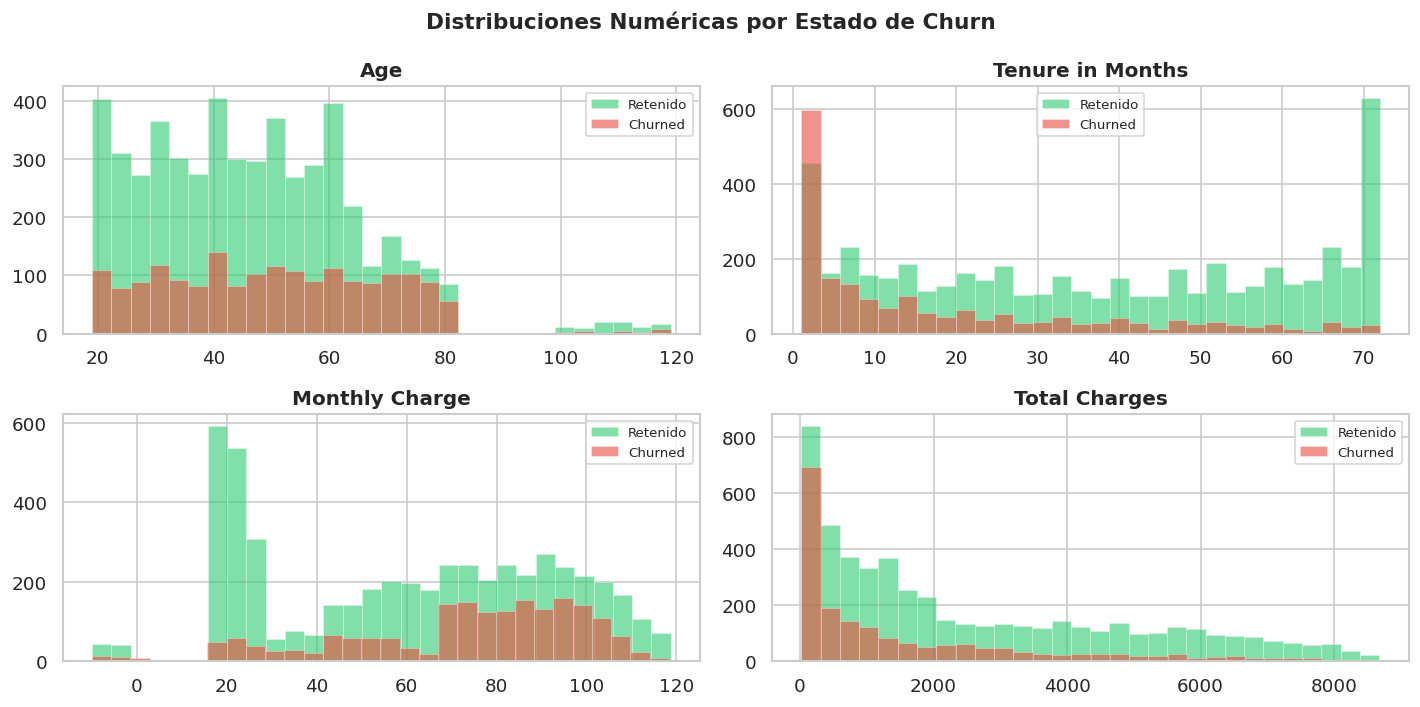

In [ ]:
# Distribuciones numéricas clave
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for val, color, label in [(0, RETAIN_COLOR, 'Retenido'), (1, CHURN_COLOR, 'Churned')]:
        ax.hist(df[df['Churned'] == val][col].dropna(),
                bins=30, alpha=0.6, color=color, label=label,
                edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones Numéricas por Estado de Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Resumen estadístico por estado de churn
df.groupby('Churned')[['Tenure in Months','Monthly Charge','Age','Population']].describe().round(1)

Tenure in Months                                           \
                   count  mean   std  min   25%   50%   75%   max   
Churned                                                             
0                 5174.0  37.6  24.1  1.0  15.0  38.0  61.0  72.0   
1                 1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0   

        Monthly Charge        ...   Age        Population                    \
                 count  mean  ...   75%    max      count     mean      std   
Churned                       ...                                             
0               5174.0  60.1  ...  59.0  119.0     5174.0  21483.0  21029.2   
1               1869.0  73.3  ...  65.0  119.0     1869.0  23957.2  21390.5   

                                                   
          min     25%      50%      75%       max  
Churned                                            
0        11.0  2156.0  16377.5  34946.0  105285.0  
1        11.0  3193.0  21349.0  39458.0  101215.0  

[2 rows x 32 columns]

In [ ]:
# Top 10 razones de churn
print('Top 10 razones de churn:')
print(df[df['Churned']==1]['Churn Reason'].value_counts().head(10))
print()
print('Categorías de churn (%):')
print((df[df['Churned']==1]['Churn Category'].value_counts(normalize=True)*100).round(1))

Top 10 razones de churn:
Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

Categorías de churn (%):
Churn Category
Competitor         45.0
Attitude           16.8
Dissatisfaction    16.2
Price              11.3
Other              10.7
Name: proportion, dtype: float64


In [ ]:
# Estadisticas numericas por grupo de churn
print('=== Comparacion de variables numericas: Churned vs Retenidos ===')
numeric_cols = ['Age','Tenure in Months','Monthly Charge','Total Revenue','Number of Referrals']
print(df.groupby('Churn Label')[numeric_cols].mean().round(2).T.to_string())

print('\n=== Churn por tipo de contrato ===')
print(df.groupby('Contract')['Churn Label'].apply(
    lambda x: (x=='Yes').mean()*100).round(1).sort_values(ascending=False))

print('\n=== Churn por tipo de internet ===')
print(df.groupby('Internet Type')['Churn Label'].apply(
    lambda x: (x=='Yes').mean()*100).round(1).sort_values(ascending=False))

=== Comparacion de variables numericas: Churned vs Retenidos ===
Churn Label               No      Yes
Age                    46.40    50.41
Tenure in Months       37.59    17.98
Monthly Charge         60.07    73.35
Total Revenue        3418.37  1971.35
Number of Referrals     2.47     0.52

=== Churn por tipo de contrato ===
Contract
Month-to-Month    45.8
One Year          10.7
Two Year           2.5
Name: Churn Label, dtype: float64

=== Churn por tipo de internet ===
Internet Type
Fiber Optic    40.7
Cable          25.7
DSL            18.6
Name: Churn Label, dtype: float64


In [ ]:
# Efecto de servicios adicionales sobre el churn
service_cols = ['Online Security','Online Backup','Device Protection Plan',
                'Premium Tech Support','Streaming TV','Streaming Movies']

print('=== Tasa de churn segun contratacion de servicios adicionales ===')
print(f'  {"Servicio":<30} {"Con servicio":>12} {"Sin servicio":>13}')
print('  ' + '-'*55)
for col in service_cols:
    yes_rate = (df[df[col]=='Yes']['Churn Label']=='Yes').mean()*100
    no_rate  = (df[df[col]=='No']['Churn Label']=='Yes').mean()*100
    diff = yes_rate - no_rate
    print(f'  {col:<30} {yes_rate:>10.1f}%  {no_rate:>10.1f}%  ({diff:+.1f}%)')

=== Tasa de churn segun contratacion de servicios adicionales ===
  Servicio                       Con servicio  Sin servicio
  -------------------------------------------------------
  Online Security                      14.6%        31.3%  (-16.7%)
  Online Backup                        21.5%        29.2%  (-7.6%)
  Device Protection Plan               22.5%        28.7%  (-6.1%)
  Premium Tech Support                 15.2%        31.2%  (-16.0%)
  Streaming TV                         30.1%        24.3%  (+5.7%)
  Streaming Movies                     29.9%        24.4%  (+5.6%)


In [ ]:
# Análisis location × population: ¿qué ciudades concentran más clientes y más churn?
city_stats = (df.groupby('City')
              .agg(Clientes=('Customer ID','count'),
                   Churned_n=('Churned','sum'),
                   Churn_rate=('Churned','mean'),
                   Poblacion=('Population','mean'))
              .reset_index())
city_stats['Churn_rate'] *= 100
city_stats.sort_values('Clientes', ascending=False).head(10)

,City,Clientes,Churned_n,Churn_rate,Poblacion
554,Los Angeles,293,78,26.621160,38631.088737
854,San Diego,285,185,64.912281,40985.214035
863,San Jose,112,29,25.892857,33231.321429
840,Sacramento,108,26,24.074074,25546.777778
857,San Francisco,104,31,29.807692,29883.538462
351,Fresno,61,13,21.311475,31249.213115
548,Long Beach,60,15,25.000000,40056.916667
690,Oakland,52,13,25.000000,30072.230769
306,Escondido,51,16,31.372549,45924.411765
957,Stockton,44,12,27.272727,28085.272727


---
## Sección Ejecutiva

### Resumen del problema

Telco presenta una **tasa de churn del 26.5%** (1,869 clientes sobre 7,043). La empresa pierde cerca de 1 de cada 4 clientes. A continuación se presentan las **5 visualizaciones clave** que explican qué factores impulsan este abandono y qué segmentos son más vulnerables.

## Visualizaciones
### Visualización 1 — Tasa de Churn por Tipo de Contrato
El tipo de contrato es el factor más determinante: los clientes Mes-a-Mes abandonan a una tasa casi 20× mayor que los de contrato bianual.

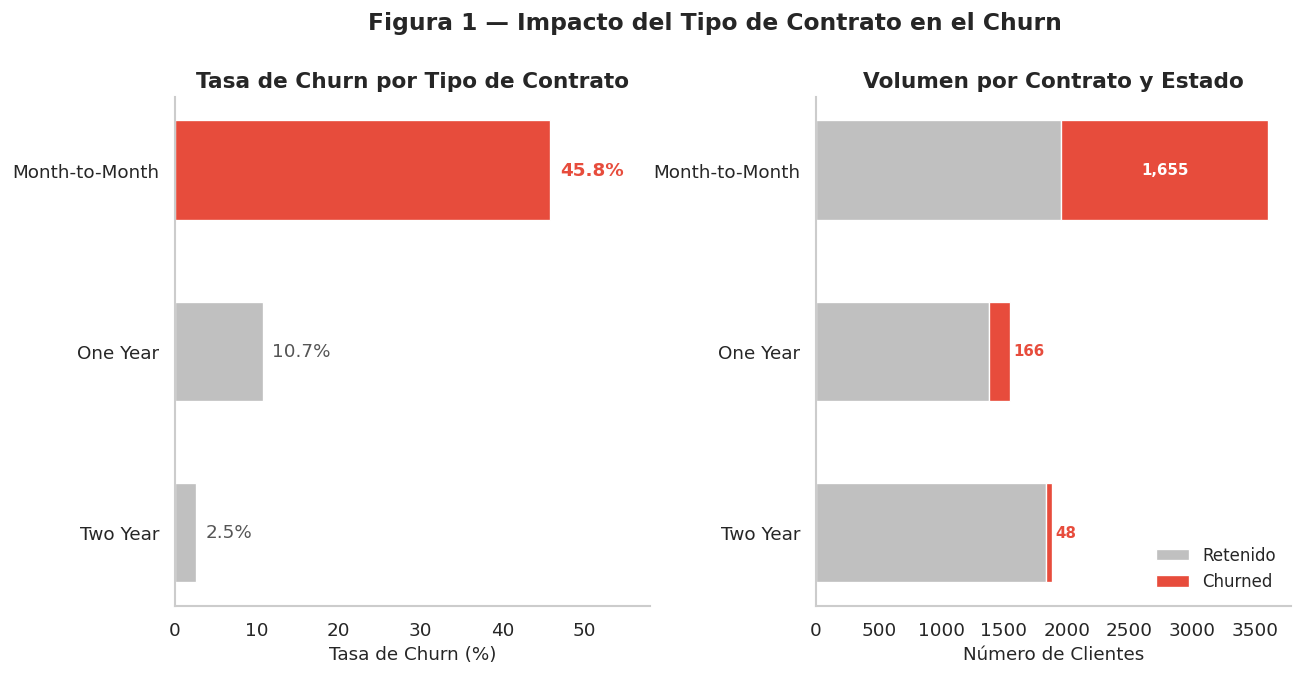

In [ ]:
# --- Figura 1: Impacto del Tipo de Contrato en el Churn ---
MUTED_COLOR = '#C0C0C0'  # Gris muted para categorías sin foco

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={'wspace': 0.35})

# --- Panel 1: Tasa de Churn por Tipo de Contrato (horizontal bar, sorted) ---
contract_churn = (df.groupby('Contract')['Churned'].mean() * 100).reset_index()
contract_churn.columns = ['Contrato', 'Churn (%)']
contract_churn = contract_churn.sort_values('Churn (%)', ascending=True)

# Color: solo la categoría con mayor churn en CHURN_COLOR, el resto muted
max_churn_idx = contract_churn['Churn (%)'].idxmax()
colors = [CHURN_COLOR if i == max_churn_idx else MUTED_COLOR
          for i in contract_churn.index]

bars = axes[0].barh(contract_churn['Contrato'], contract_churn['Churn (%)'],
                    color=colors, edgecolor='white', linewidth=0.8, height=0.55)

# Etiquetas directas sobre las barras
for bar, val in zip(bars, contract_churn['Churn (%)']):
    is_highlight = (val == contract_churn['Churn (%)'].max())
    axes[0].text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%',
                 va='center', ha='left',
                 fontweight='bold' if is_highlight else 'normal',
                 fontsize=11,
                 color=CHURN_COLOR if is_highlight else '#555555')

axes[0].set_title('Tasa de Churn por Tipo de Contrato', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tasa de Churn (%)', fontsize=11)
axes[0].set_xlim(0, 58)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# --- Panel 2: Volumen de Clientes (stacked horizontal bar, churn resaltado) ---
contract_count = df.groupby(['Contract', 'Churned']).size().unstack(fill_value=0)
contract_count.columns = ['Retenido', 'Churned']
# Reordenar igual que panel 1
contract_count = contract_count.loc[contract_churn['Contrato']]

bar_ret = axes[1].barh(contract_count.index, contract_count['Retenido'],
                       color=MUTED_COLOR, edgecolor='white', linewidth=0.8,
                       height=0.55, label='Retenido')
bar_ch = axes[1].barh(contract_count.index, contract_count['Churned'],
                      left=contract_count['Retenido'],
                      color=CHURN_COLOR, edgecolor='white', linewidth=0.8,
                      height=0.55, label='Churned')

# Etiquetas: dentro (blanco) si el segmento es ancho, fuera (rojo) si es angosto
max_total = contract_count.sum(axis=1).max()
for bar, val in zip(bar_ch, contract_count['Churned']):
    if val > 0:
        if bar.get_width() / max_total > 0.12:
            # Segmento ancho → etiqueta dentro, texto blanco
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + bar.get_height() / 2,
                         f'{val:,}', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='white')
        else:
            # Segmento angosto → etiqueta fuera a la derecha, texto rojo
            axes[1].text(bar.get_x() + bar.get_width() + 25,
                         bar.get_y() + bar.get_height() / 2,
                         f'{val:,}', ha='left', va='center',
                         fontsize=9, fontweight='bold', color=CHURN_COLOR)

axes[1].set_title('Volumen por Contrato y Estado', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Número de Clientes', fontsize=11)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)
axes[1].legend(loc='lower right', fontsize=10, frameon=False)

fig.suptitle('Figura 1 — Impacto del Tipo de Contrato en el Churn',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Visualización 2 — Antigüedad del Cliente vs Churn
El mayor riesgo de abandono ocurre durante los primeros 6 meses de vida del cliente. Quien supera los 2 años tiene muy baja probabilidad de churn.

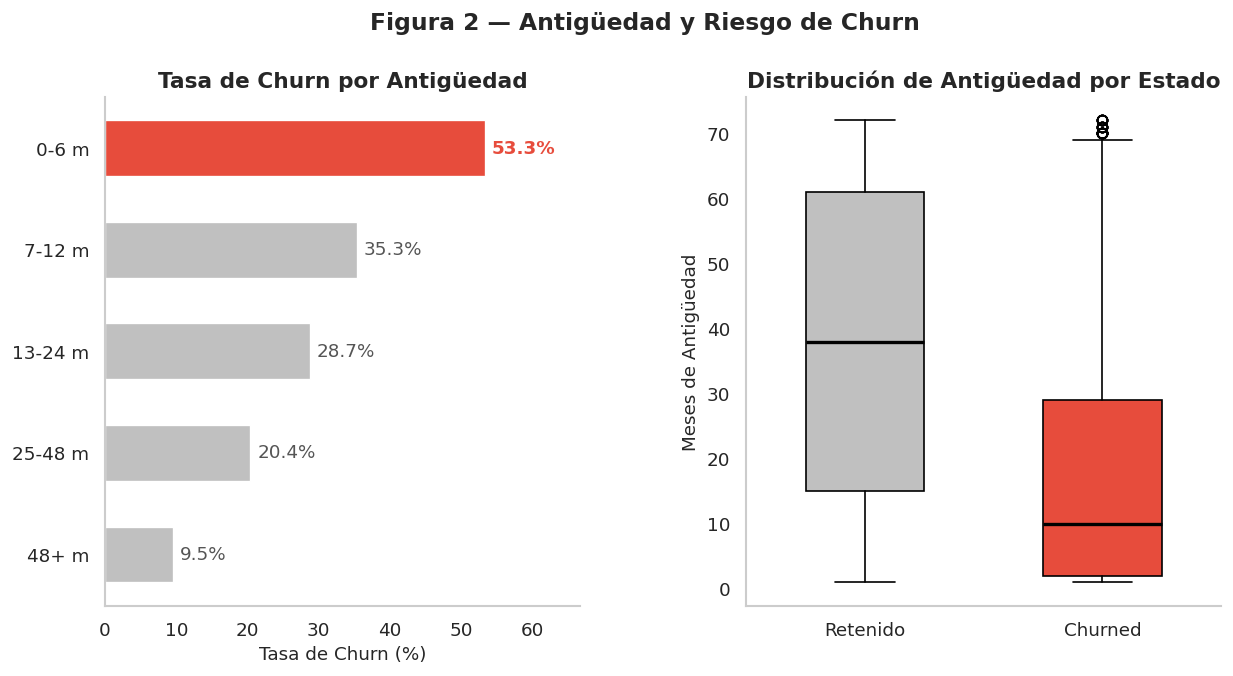

In [ ]:
# --- Figura 2: Antigüedad y Riesgo de Churn ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={'wspace': 0.35})

# --- Panel 1: Tasa de Churn por Antigüedad (horizontal bar, sorted) ---
tenure_churn = (df.groupby('Tenure_Segment', observed=True)['Churned'].mean() * 100).reset_index()
tenure_churn.columns = ['Antigüedad', 'Churn (%)']
tenure_churn = tenure_churn.sort_values('Churn (%)', ascending=True)

# Color: solo la categoría con mayor churn en CHURN_COLOR, el resto muted
max_idx = tenure_churn['Churn (%)'].idxmax()
colors = [CHURN_COLOR if i == max_idx else MUTED_COLOR for i in tenure_churn.index]

bars = axes[0].barh(tenure_churn['Antigüedad'], tenure_churn['Churn (%)'],
                    color=colors, edgecolor='white', linewidth=0.8, height=0.55)

for bar, val in zip(bars, tenure_churn['Churn (%)']):
    is_highlight = (val == tenure_churn['Churn (%)'].max())
    axes[0].text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', ha='left',
                 fontweight='bold' if is_highlight else 'normal',
                 fontsize=11,
                 color=CHURN_COLOR if is_highlight else '#555555')

axes[0].set_title('Tasa de Churn por Antigüedad', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tasa de Churn (%)', fontsize=11)
axes[0].set_xlim(0, max(tenure_churn['Churn (%)']) * 1.25)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# --- Panel 2: Boxplot de Antigüedad por Estado ---
bplot = axes[1].boxplot(
    [df[df['Churned'] == 0]['Tenure in Months'], df[df['Churned'] == 1]['Tenure in Months']],
    patch_artist=True, labels=['Retenido', 'Churned'],
    medianprops=dict(color='black', linewidth=2),
    widths=0.5)
for patch, color in zip(bplot['boxes'], [MUTED_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color)

axes[1].set_title('Distribución de Antigüedad por Estado', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Meses de Antigüedad', fontsize=11)
axes[1].tick_params(axis='both', labelsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

fig.suptitle('Figura 2 — Antigüedad y Riesgo de Churn',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Visualización 3 — Categorías y Razones de Churn
La competencia (precio y oferta) es la principal causa de abandono, representando más del 40% de los churns. Esto indica que nuestra Telco enfrenta presión directa del mercado.

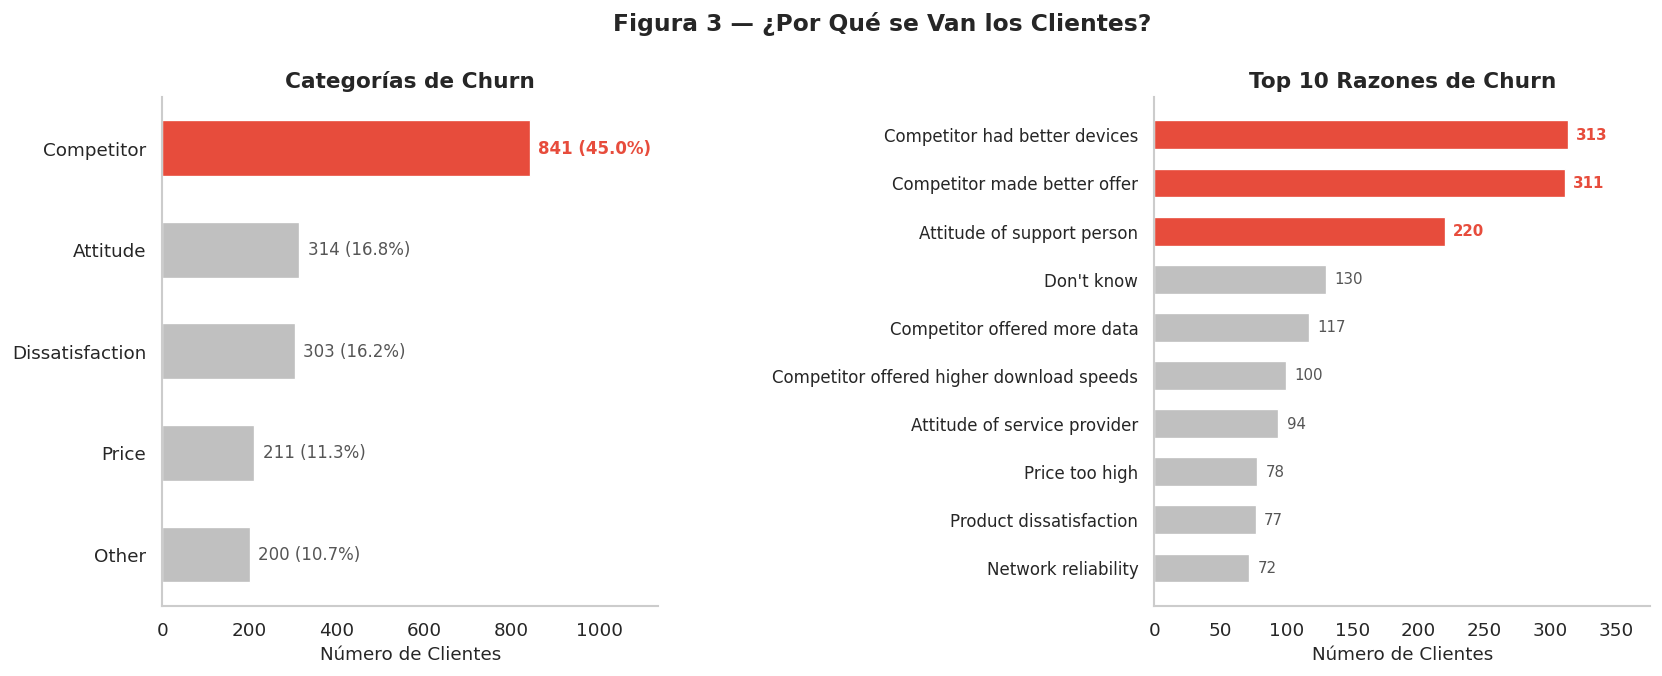

In [ ]:
# --- Figura 3: ¿Por Qué se Van los Clientes? ---
churned_df = df[df['Churned'] == 1].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'wspace': 1.0})

# --- Panel 1: Categorías de Churn (horizontal bar en lugar de pie) ---
cat_counts = churned_df['Churn Category'].value_counts().sort_values(ascending=True)
max_cat = cat_counts.idxmax()
cat_colors = [CHURN_COLOR if cat == max_cat else MUTED_COLOR for cat in cat_counts.index]

bars_cat = axes[0].barh(cat_counts.index, cat_counts.values,
                        color=cat_colors, edgecolor='white', linewidth=0.8, height=0.55)

total = cat_counts.sum()
for bar, val in zip(bars_cat, cat_counts.values):
    is_top = (val == cat_counts.max())
    pct = val / total * 100
    axes[0].text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({pct:.1f}%)', va='center', ha='left',
                 fontweight='bold' if is_top else 'normal',
                 fontsize=10,
                 color=CHURN_COLOR if is_top else '#555555')

axes[0].set_title('Categorías de Churn', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Número de Clientes', fontsize=11)
axes[0].set_xlim(0, cat_counts.max() * 1.35)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# --- Panel 2: Top 10 Razones de Churn (horizontal bar, top 3 resaltadas) ---
reasons = churned_df['Churn Reason'].value_counts().head(10).sort_values(ascending=True)
top3_vals = reasons.nlargest(3).index
reason_colors = [CHURN_COLOR if r in top3_vals else MUTED_COLOR for r in reasons.index]

bars_reason = axes[1].barh(reasons.index, reasons.values,
                           color=reason_colors, edgecolor='white', linewidth=0.8, height=0.6)

for bar, (reason, val) in zip(bars_reason, reasons.items()):
    is_top = reason in top3_vals
    axes[1].text(bar.get_width() + reasons.max() * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', ha='left',
                 fontweight='bold' if is_top else 'normal',
                 fontsize=9,
                 color=CHURN_COLOR if is_top else '#555555')

axes[1].set_title('Top 10 Razones de Churn', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Número de Clientes', fontsize=11)
axes[1].set_xlim(0, reasons.max() * 1.2)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

fig.suptitle('Figura 3 — ¿Por Qué se Van los Clientes?',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Visualización 4 — Servicios Adicionales como Anclas de Retención
Para casi todos los servicios, los clientes que NO los contratan presentan tasas de churn mucho mayores. Cada servicio adicional actúa como un "ancla" que reduce el abandono.

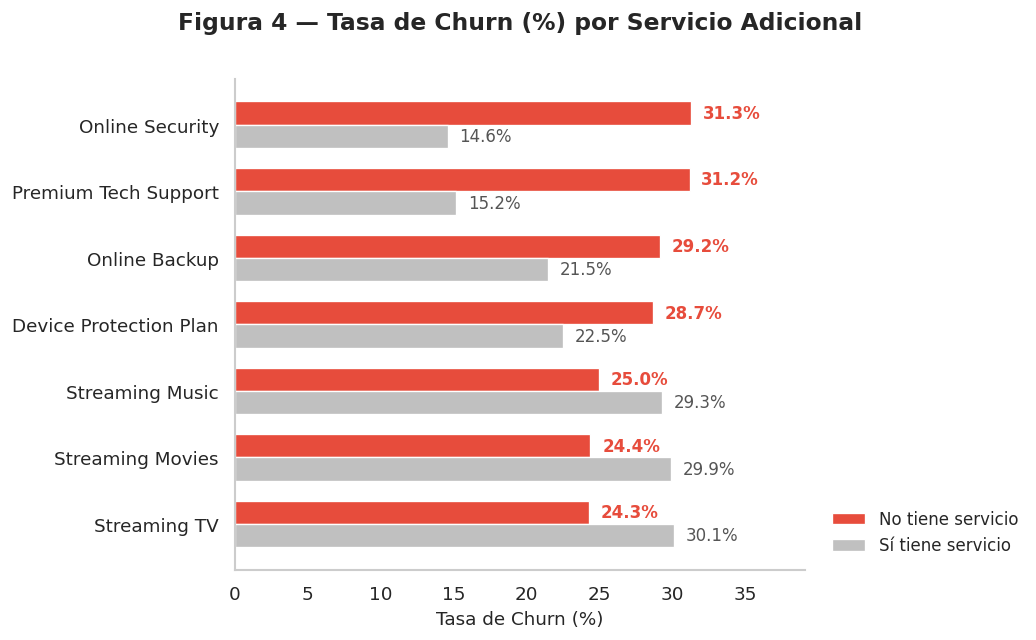

In [ ]:
# --- Figura 4: Servicios Adicionales como Anclas de Retención ---
import numpy as np

service_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music'
]

records = []
for col in service_cols:
    for val in ['No', 'Yes']:
        sub = df[df[col] == val]
        if len(sub) > 0:
            records.append({'Servicio': col, 'Estado': val,
                            'Churn (%)': round(sub['Churned'].mean() * 100, 1)})

svc_df = pd.DataFrame(records)
pivot = svc_df.pivot(index='Servicio', columns='Estado', values='Churn (%)')

# Ordenar por diferencia (gap) descendente → servicios con mayor efecto ancla arriba
pivot['Gap'] = pivot['No'] - pivot['Yes']
pivot = pivot.sort_values('Gap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))

y = np.arange(len(pivot))
bar_h = 0.35

# "No tiene servicio" en CHURN_COLOR (alto riesgo), "Sí tiene" en MUTED
bars_no = ax.barh(y + bar_h / 2, pivot['No'], height=bar_h,
                  color=CHURN_COLOR, edgecolor='white', linewidth=0.8, label='No tiene servicio')
bars_yes = ax.barh(y - bar_h / 2, pivot['Yes'], height=bar_h,
                   color=MUTED_COLOR, edgecolor='white', linewidth=0.8, label='Sí tiene servicio')

# Etiquetas directas
for bar, val in zip(bars_no, pivot['No']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=10, fontweight='bold', color=CHURN_COLOR)
for bar, val in zip(bars_yes, pivot['Yes']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=10, color='#555555')

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_xlabel('Tasa de Churn (%)', fontsize=11)
ax.set_xlim(0, pivot['No'].max() * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(loc='lower right', fontsize=10, frameon=False,
          bbox_to_anchor=(1.4, 0))

ax.set_title('Figura 4 — Tasa de Churn (%) por Servicio Adicional',
             fontweight='bold', fontsize=14, pad=30)
fig.tight_layout()
plt.show()

### Visualización 5 — Densidad Poblacional vs Churn (location × population)
Al cruzar la información geográfica (`location.csv`) con la demografía de los códigos postales (`population.csv`), emergen patrones sobre cómo el entorno urbano influye en el comportamiento de los clientes.

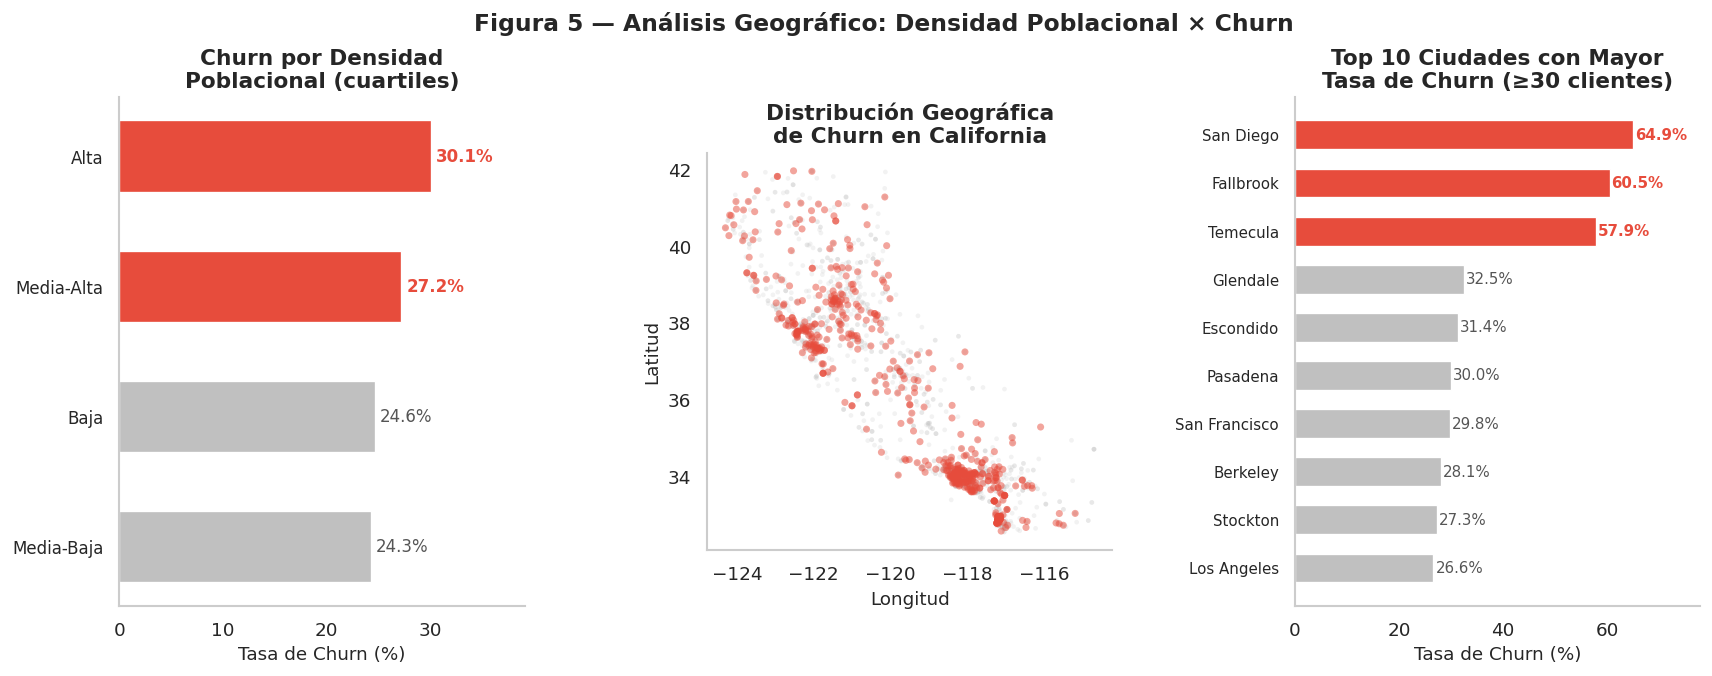

In [ ]:
# --- Figura 5: Análisis Geográfico: Densidad Poblacional × Churn ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), gridspec_kw={'wspace': 0.45})

# --- Panel 1: Tasa de churn por cuartil de población (horizontal bar, sorted) ---
pop_churn = (df.groupby('Pop_Segment', observed=True)['Churned']
             .mean() * 100).reset_index()
pop_churn.columns = ['Densidad', 'Churn (%)']
pop_churn = pop_churn.sort_values('Churn (%)', ascending=True)

# Resaltar las dos categorías con mayor churn
top2_vals = pop_churn.nlargest(2, 'Churn (%)')['Densidad'].tolist()
bar_colors = [CHURN_COLOR if d in top2_vals else MUTED_COLOR for d in pop_churn['Densidad']]

bars = axes[0].barh(pop_churn['Densidad'], pop_churn['Churn (%)'],
                    color=bar_colors, edgecolor='white', linewidth=0.8, height=0.55)
for bar, (_, row) in zip(bars, pop_churn.iterrows()):
    is_top = row['Densidad'] in top2_vals
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{row["Churn (%)"]:.1f}%', va='center', ha='left',
                 fontweight='bold' if is_top else 'normal', fontsize=10,
                 color=CHURN_COLOR if is_top else '#555555')

axes[0].set_title('Churn por Densidad\nPoblacional (cuartiles)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tasa de Churn (%)', fontsize=11)
axes[0].set_xlim(0, pop_churn['Churn (%)'].max() * 1.3)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# --- Panel 2: Mapa geográfico de churn (scatter lat/lon) ---
sample = df.sample(min(2000, len(df)), random_state=42)
# Retenidos primero (fondo), Churned encima
retained = sample[sample['Churned'] == 0]
churned = sample[sample['Churned'] == 1]

axes[1].scatter(retained['Longitude'], retained['Latitude'],
                c=MUTED_COLOR, s=8, alpha=0.2, edgecolors='none')
axes[1].scatter(churned['Longitude'], churned['Latitude'],
                c=CHURN_COLOR, s=18, alpha=0.5, edgecolors='none')

axes[1].set_title('Distribución Geográfica\nde Churn en California', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Longitud', fontsize=11)
axes[1].set_ylabel('Latitud', fontsize=11)
axes[1].set_aspect('equal')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

# --- Panel 3: Top 10 ciudades con mayor tasa de churn (horizontal bar, top 3 resaltadas) ---
city_stats = (df.groupby('City')
              .agg(Clientes=('Customer ID', 'count'),
                   Churn_rate=('Churned', 'mean'))
              .reset_index())
city_stats['Churn_rate'] *= 100
top_cities = (city_stats[city_stats['Clientes'] >= 30]
              .sort_values('Churn_rate', ascending=True)
              .tail(10))

top3_cities = top_cities.nlargest(3, 'Churn_rate')['City'].tolist()
bar_colors3 = [CHURN_COLOR if c in top3_cities else MUTED_COLOR for c in top_cities['City']]

axes[2].barh(top_cities['City'], top_cities['Churn_rate'],
             color=bar_colors3, edgecolor='white', linewidth=0.8, height=0.6)

for i, (_, row) in enumerate(top_cities.iterrows()):
    is_top = row['City'] in top3_cities
    axes[2].text(row['Churn_rate'] + 0.4, i,
                 f"{row['Churn_rate']:.1f}%", va='center',
                 fontsize=9, fontweight='bold' if is_top else 'normal',
                 color=CHURN_COLOR if is_top else '#555555')

axes[2].set_title('Top 10 Ciudades con Mayor\nTasa de Churn (≥30 clientes)', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Tasa de Churn (%)', fontsize=11)
axes[2].set_xlim(0, top_cities['Churn_rate'].max() * 1.2)
axes[2].tick_params(axis='y', labelsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].grid(False)

fig.suptitle('Figura 5 — Análisis Geográfico: Densidad Poblacional × Churn',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

---
## Recomendaciones

### Recomendación 1: Migración a contratos de mayor duración

En la Figura 1, los contratos Mes-a-Mes presentan ~45.8% de churn vs 2.5% en contratos de 2 años.

**Acciónes Concretas:**
-  Diseñar incentivos de migración (descuentos del 15-20%, bonificación de datos) para convertir clientes Mes-a-Mes a contratos anuales. Priorizar clientes con antigüedad < 12 meses (zona de mayor riesgo según Figura 2).
- Elaborar campañas dirigidas a clientes mes a mes con más de 3 meses de antigüedad sin historial de reclamaciones (segmento con mayor probabilidad de conversión).
- Automatizar alertas para que el equipo comercial contacte a clientes mes a mes próximos a cumplir 6 meses
**Impacto esperado:** Lograr el 30% de conversión de Mes-a-Mes reduciría la churn rate global del ~26.5% al ~18%.

### Recomendación 2: Bundle de Servicios para Clientes de Alto Riesgo

En la Figura 4, los clientes sin Seguridad Online, Soporte Premium o Backup presentan tasas de churn de 40-50%, mientras que quienes sí los tienen bajan al 15-20%.

**Acciones Concretas:**
- Identificar clientes en riesgo (mes a mes, primeros 12 meses) que **no tienen Seguridad Online ni Soporte Premium**, y ofrecerles 3 meses gratuitos de esos servicios.
- Ofrecer un bundle de valor a precio especial (Seguridad + Backup + Soporte) dirigido a clientes de Fibra Óptica sin servicios adicionales, que son el segmento de mayor riesgo. Cada servicio adicional actúa como "ancla" de retención.

**Impacto esperado:** Clientes con 3+ servicios adicionales tienen churn < 10%. Elevar la adopción puede reducir su churn en 20+ puntos porcentuales.

### Recomendación 3: Programa de Contraoferta ante la Competencia

En la Figura 3 — más del 40% de los churns son causados por la competencia (mejor precio, más datos, mejor oferta).

**Acción:** Implementar un sistema de contraoferta proactiva: al detectar señales de intención de churn (llamadas a retención, consultas de portabilidad), generar automáticamente una oferta personalizada. Capacitar a agentes con autorización para ofrecer descuentos de hasta 20% sin escalamiento.

**Impacto esperado:** Las empresas telco con contraoferta proactiva reportan reducciones de churn del 15-25% en el segmento en riesgo.